# **6-2. 자연어 처리 기초**

In [ ]:
# 판다스 라이브러리 불러오기
import pandas as pd
# konlpy 설치 [LMS 에는 이미 설치가 되어 있습니다.]
!pip install konlpy
# 라이브러리 불러오기 (okt)
import konlpy
from konlpy.tag import Okt
tokenizer = Okt()

In [ ]:
# 토큰화 (형태소 단위)
text = "함께 탐험하며, 성장하는 AI 학교 AIFFEL"
tokenizer.morphs(text)

['함께', '탐험', '하며', ',', '성장하는', 'AI', '학교', 'AIFFEL']

In [ ]:
# 토큰화 (명사만)
tokenizer.nouns(text)

['탐험', '학교']

In [ ]:
# 토큰화 (품사태깅)
tokenizer.pos(text)

[('함께', 'Adverb'),
 ('탐험', 'Noun'),
 ('하며', 'Verb'),
 (',', 'Punctuation'),
 ('성장하는', 'Adjective'),
 ('AI', 'Alpha'),
 ('학교', 'Noun'),
 ('AIFFEL', 'Alpha')]

## CountVextorizer

In [ ]:
# CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()

In [ ]:
# 단어 토큰화 (Okt)
words = tokenizer.morphs(text)

In [ ]:
# 데이터 학습
vect.fit(words)

CountVectorizer()

In [ ]:
# 학습된 어휘
vect.get_feature_names_out()

array(['ai', 'aiffel', '성장하는', '탐험', '하며', '학교', '함께'], dtype=object)

In [ ]:
# 단어 사전
vect.vocabulary_

{'함께': 6, '탐험': 3, '하며': 4, '성장하는': 2, 'ai': 0, '학교': 5, 'aiffel': 1}

In [ ]:
# 단어 사전 크기
len(vect.vocabulary_)

7

In [ ]:
# 인코딩
df_t = vect.transform(words)

In [ ]:
# 인코딩된 데이터 Matrix
df_t.toarray()

array([[0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 0, 0]])

In [ ]:
# 어휘와 피처
import pandas as pd
pd.DataFrame(df_t.toarray(), columns=vect.get_feature_names_out())

,ai,aiffel,성장하는,탐험,하며,학교,함께
0,0,0,0,0,0,0,1
1,0,0,0,1,0,0,0
2,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0
5,1,0,0,0,0,0,0
6,0,0,0,0,0,1,0
7,0,1,0,0,0,0,0


In [ ]:
# test
test = "AI 공부하며 함께 성장해요!"

In [ ]:
# 단어 토큰화 (Okt)
words = tokenizer.morphs(test)
words

['AI', '공부', '하며', '함께', '성장해요', '!']

In [ ]:
# 인코딩된 데이터 Matrix
test_t = vect.transform(words)
test_t.toarray()

array([[1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0]])

In [ ]:
# 어휘와 피처
pd.DataFrame(test_t.toarray(), columns=vect.get_feature_names_out())

,ai,aiffel,성장하는,탐험,하며,학교,함께
0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0


## TfidfVectorizer

In [ ]:
#tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# tf-idf
vect = TfidfVectorizer()
words = tokenizer.morphs(text)
vect.fit(words)
vect.vocabulary_

{'함께': 6, '탐험': 3, '하며': 4, '성장하는': 2, 'ai': 0, '학교': 5, 'aiffel': 1}

In [ ]:
vect.transform(words).toarray()

array([[0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0.]])

# **6-3. 감성 분석**

## 데이터 불러오기

In [ ]:
# 라이브러리 불러오기
import pandas as pd

In [ ]:
# 데이터 불러오기
df = pd.read_csv("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", sep="\t")

## EDA 및 데이터 전처리

In [ ]:
# 데이터 샘플
df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [ ]:
# 데이터 크기
df.shape

(150000, 3)

In [ ]:
# 타겟 확인
df['label'].value_counts()

,count
label,
0,75173
1,74827


In [ ]:
# 결측치
df.isnull().sum()

,0
id,0
document,5
label,0


In [ ]:
# 결측치 삭제
print(df.shape)
df = df.dropna()
print(df.shape)

(150000, 3)
(149995, 3)


In [ ]:
# 피처 엔지니어링 (문장의 길이)
df['len'] = df['document'].apply(len)
df.head()

,id,document,label,len
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,19
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,33
2,10265843,너무재밓었다그래서보는것을추천한다,0,17
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,29
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,61


<Axes: ylabel='Frequency'>

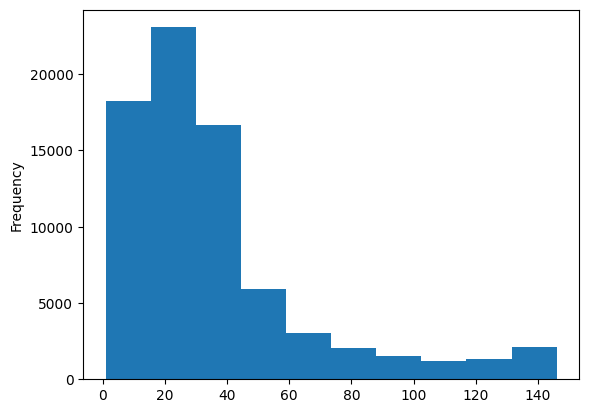

In [ ]:
# len 시각화 (label == 0)
import matplotlib.pyplot as plt
df[df.label==0]['len'].plot(kind='hist')

<Axes: ylabel='Frequency'>

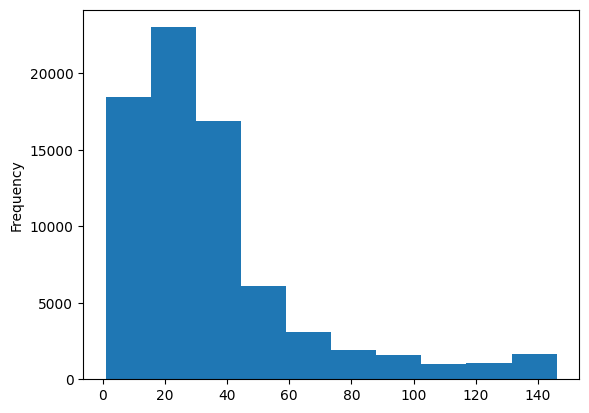

In [ ]:
# len 시각화 (label == 1)
df[df.label==1]['len'].plot(kind='hist')

In [ ]:
# 데이터 샘플링
df = df[:1000]

In [ ]:
# 토큰화
vect = CountVectorizer(tokenizer=tokenizer.morphs)
vectors = vect.fit_transform(df['document'])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


## 머신러닝 > 교차검증

- [리마인드] 교차검증이란?

  - 일반적으로 모델을 학습시킬 때 데이터를 train set과 test set으로 나누어 train set을 가지고 학습을 수행합니다.
  - 교차검증이란 여기서 train set을 다시 train set과 validation set으로 나누어 학습 중 검증과 수정을 수행하는 것을 의미합니다.

- [리마인드] F1 이란?
  - 분류 모델의 평가 지표 중 하나로, 정밀도(precision)와 재현율(recall)의 조화평균을 나타냅니다.


- <참고> 5. 지도학습(분류) 노드의 5-5. 교차검증, 5-6. 평가(분류) 스텝에서 복습하실 수 있습니다.

In [ ]:
# 머신러닝
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(random_state=2022)
cross_val_score(model, vectors, df['label'], scoring='f1', cv=5).mean()

np.float64(0.6634352457852256)

# **6-4. 자연어 전처리**

## 어휘사전 구축

In [ ]:
# 토큰화(max_df) N개 보다 큰 단어 수 무시
vect = CountVectorizer(tokenizer=tokenizer.morphs, max_df=10)
vectors = vect.fit_transform(df['document'])
model = RandomForestClassifier(random_state=2022)
cross_val_score(model, vectors, df['label'], scoring='accuracy', cv=5).mean()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


np.float64(0.643)

In [ ]:
# 토큰화(min_df) N개 보다 작은 단어 수 무시
vect = CountVectorizer(tokenizer=tokenizer.morphs, min_df=2)
vectors = vect.fit_transform(df['document'])
model = RandomForestClassifier(random_state=2022)
cross_val_score(model, vectors, df['label'], scoring='accuracy', cv=5).mean()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


np.float64(0.689)

## 불용어 (stopword)

In [ ]:
# stop_words
stop_words = ['에서','해요']
vect = CountVectorizer(stop_words=stop_words)
words = tokenizer.morphs(text)
vect.fit(words)
vect.vocabulary_

{'함께': 6, '탐험': 3, '하며': 4, '성장하는': 2, 'ai': 0, '학교': 5, 'aiffel': 1}

## 띄어쓰기
- 더 자세히: https://github.com/haven-jeon/PyKoSpacing

In [ ]:
# Spacing 설치
!pip install git+https://github.com/haven-jeon/PyKoSpacing.git

  Cloning https://github.com/haven-jeon/PyKoSpacing.git to /tmp/pip-req-build-ck85hl8n
  Running command git clone --filter=blob:none --quiet https://github.com/haven-jeon/PyKoSpacing.git /tmp/pip-req-build-ck85hl8n
  Resolved https://github.com/haven-jeon/PyKoSpacing.git to commit b32a889cbd10b006d2f4aba118f0cd5b677e2979
  Preparing metadata (setup.py) ... done
  Created wheel for pykospacing: filename=pykospacing-0.5-py3-none-any.whl size=2286920 sha256=518ed28dd32beb43d550327e3cd110c871f03eef2ed16e0eae82f0d28bb5567c
  Stored in directory: /tmp/pip-ephem-wheel-cache-o699juwb/wheels/76/1f/66/ecf5b2f136847d084f6e9af3c732f2899ee9f9b229a45aa8b8
Successfully built pykospacing


In [ ]:
# 띄어쓰기
from pykospacing import Spacing
spacing = Spacing()

text = "함께탐험하며성장하는AI학교아이펠"
spacing_test = spacing(text)
print(text)
print(spacing_test)

KeyboardInterrupt: 

## 반복되는 글자 정리
- 더 자세히: https://github.com/lovit/soynlp

In [ ]:
# soynlp 설치
!pip install soynlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.8/416.8 kB 17.0 MB/s eta 0:00:00


In [ ]:
# 댓글 데이터에 등장하는 반복되는 이모티콘의 정리
from soynlp.normalizer import *

emoticon_normalize('하하하하ㅋㅋㅋㅋㅋㅠㅠㅠㅠㅠㅠ', num_repeats=3)

'하하하ㅋㅋㅋㅠㅠㅠ'

## 맞춤법 검사기
- 더 자세히: https://github.com/ssut/py-hanspell
- 갑작스러운 정책 변경으로 hanspell 사용이 불가능한 상황입니다. 이슈가 해결되는 대로 업데이트하겠습니다.





In [ ]:
# py-hanspell 설치
!pip install git+https://github.com/ssut/py-hanspell.git

  Cloning https://github.com/ssut/py-hanspell.git to /tmp/pip-req-build-p_ejfwc7
  Running command git clone --filter=blob:none --quiet https://github.com/ssut/py-hanspell.git /tmp/pip-req-build-p_ejfwc7
  Resolved https://github.com/ssut/py-hanspell.git to commit fdc6ca50c19f1c85971437a072d89d4e5ce024b8
  Preparing metadata (setup.py) ... done
  Created wheel for py-hanspell: filename=py_hanspell-1.1-py3-none-any.whl size=4812 sha256=28250af9bb92b1d487d4a623f5d6b0174802cc423ca1e5d2721d232303ca7234
  Stored in directory: /tmp/pip-ephem-wheel-cache-13zk_7ew/wheels/17/cd/d3/1046f3c4c2ee945775e6f1585962648813dbeda3a69f5b2b63
Successfully built py-hanspell


In [ ]:
# 맞춤법 검사
from hanspell import spell_checker
text = '알파고 이전, 2015년부터 만들 어진 최초의AI 커뮤니티 모두의연구소.학연, 지연, 모두연이라는 말이나올만큼 AI의 보금자리로서 중요한 역할을 하고있는 모두의연구소에서 만들었습니다. AI기술을 커뮤니티로 배우는 유일 한 기관 아이펠과 함께 밝은 미래를 만들어보세요.'
result = spell_checker.check(text)
result.as_dict()

KeyError: 'result'

In [ ]:
# 수정된 문장
result.checked